# Chirundu Town Council CDF Community Projects - 2025

## Purpose

This notebook extracts, cleans, validates and exports approved
CDF community project information published by Chirundu Town Council.

The source PDF is scanned, therefore OCR is used to extract the text
before the records are cleaned and structured.

## Final Dataset Fields

- project_name
- ward
- year
- approval_status
- project_type

In [1]:
import os
import pymupdf
import pytesseract
import pandas as pd
import cv2
import numpy as np

from PIL import Image
from IPython.display import display

pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Program Files\Tesseract-OCR\tesseract.exe"
)

print("Libraries loaded successfully.")
print("Tesseract version:", pytesseract.get_tesseract_version())

Libraries loaded successfully.
Tesseract version: 5.4.0.20240606


## Source Document

The source document is the 2025 Chirundu Town Council approved CDF
community projects PDF.

The document contains a scanned table with project names and wards.

Unlike some earlier source documents, the 2025 table does not contain
a Sector column. Therefore, project type is classified during data
curation from the project description.

In [2]:
pdf_path = "raw/2025-CDF-Approved-Community-Projects.pdf"

print("File exists:", os.path.exists(pdf_path))

File exists: True


In [3]:
doc = pymupdf.open(pdf_path)

print("PDF opened successfully.")
print("Number of pages:", len(doc))

PDF opened successfully.
Number of pages: 1


## Direct Text Extraction Test

Before applying OCR, the notebook checks whether useful
machine-readable text can be extracted directly from the PDF.

Because the source document is scanned, little or no useful text is
expected from direct extraction.

In [4]:
for page_number, page in enumerate(doc):
    text = page.get_text().strip()

    print(
        f"Page {page_number + 1}:",
        len(text),
        "characters detected"
    )

Page 1: 10 characters detected


## OCR Extraction

The scanned PDF page is converted to a high-resolution image and
processed using Tesseract OCR.

The OCR output is later compared with the original PDF because OCR may
misread characters, merge rows or fail to capture some entries.

In [5]:
os.makedirs("notebooks/2025_ocr", exist_ok=True)

page = doc[0]

matrix = pymupdf.Matrix(3, 3)

pix = page.get_pixmap(
    matrix=matrix,
    alpha=False
)

image_path = "notebooks/2025_ocr/2025_cdf_page1.png"

pix.save(image_path)

print("Page image saved successfully:")
print(image_path)

Page image saved successfully:
notebooks/2025_ocr/2025_cdf_page1.png


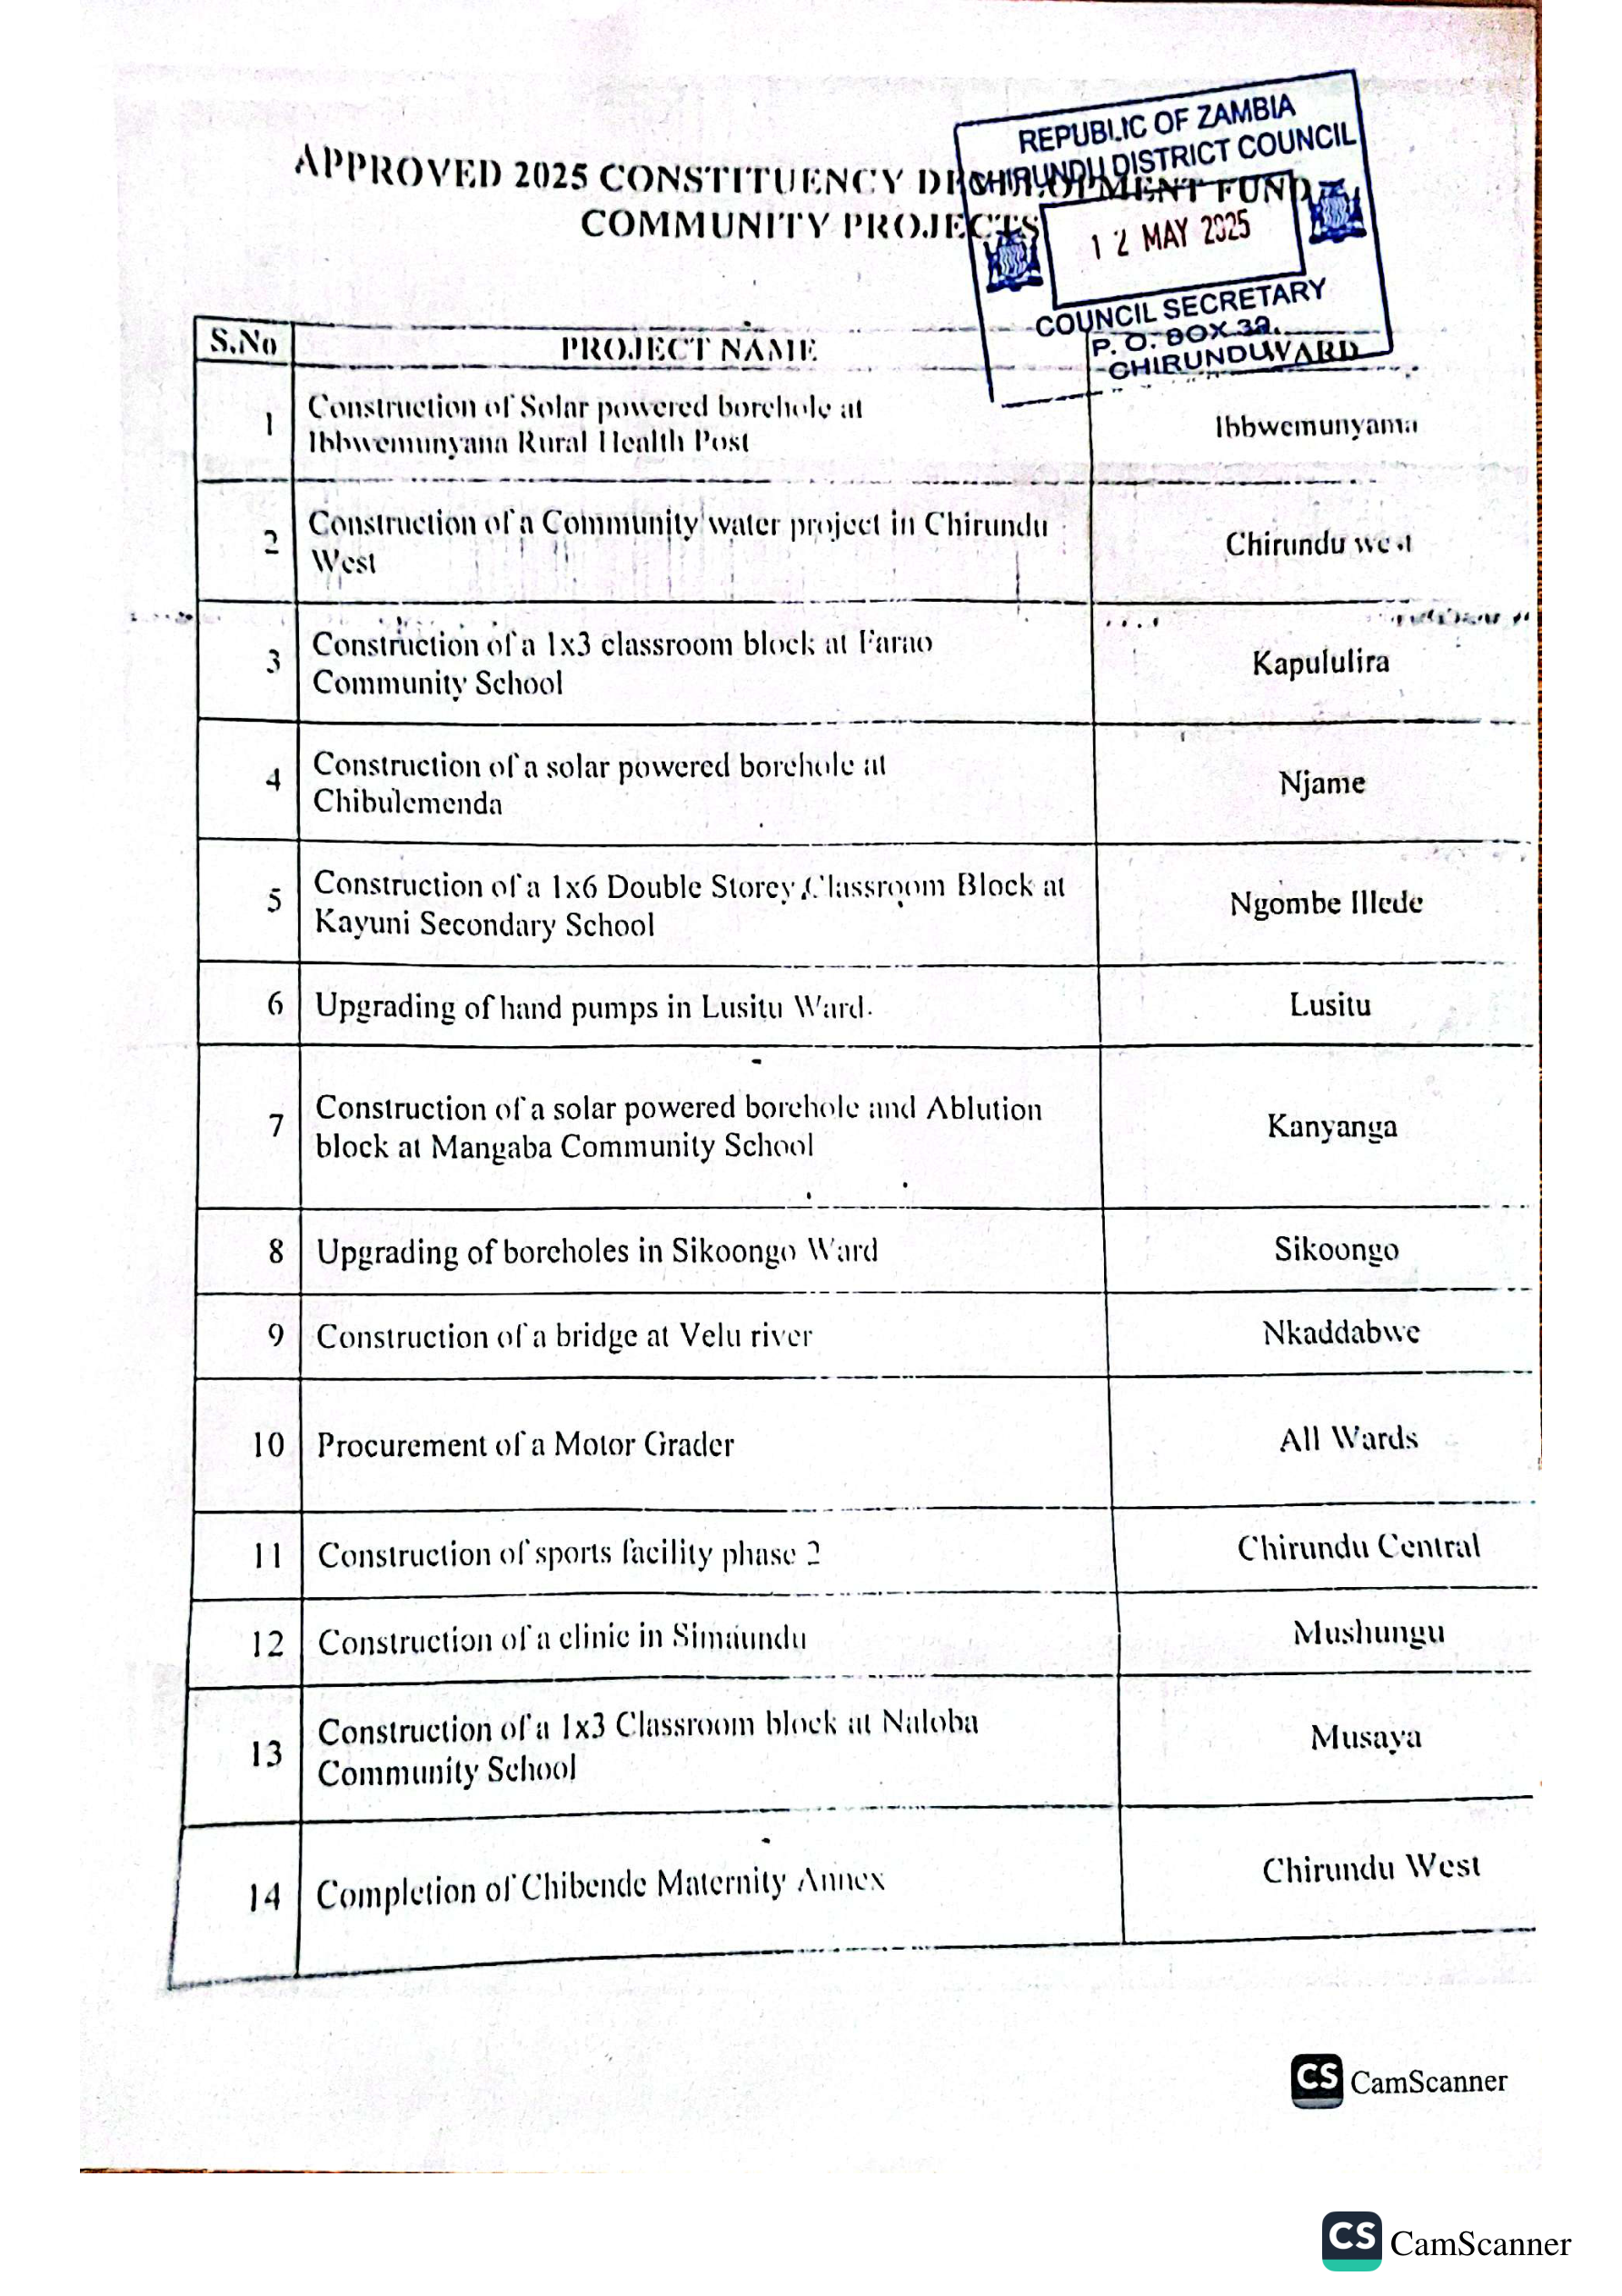

In [6]:
page_image = Image.open(image_path)

display(page_image)

In [7]:
image = cv2.imread(image_path)

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

ocr_text_2025 = pytesseract.image_to_string(
    gray,
    lang="eng",
    config="--psm 6"
)

print(ocr_text_2025)

OF ZAMBIA
REPUBLIC OUNCIL
p . 5 . \CT C'
API ROVED 2025 CONSTITUENCY DI CHA Vie 0 7
COMMUNITY PROVE a)
: Y
SECRETAR
: BR a RI OE eel COUNCIL SE sa.
S.No} PROJECT NAME |" POR GNOWVARE
1 Construction of Solar powered boreholy at ap ee
Ibbwemunyana Rural Health Post CDEeCHTICITTY RIN I
4 | Construction ofa Community water project in Chirundu at
— | Wes oy ; ; Chirundu wet H
\ est \ : 4 ; |
slantiain SNS, eo We a Sates assy soe pO aces .
3 | Construction ofa 1x3 classroom block at Farao : Coaililia: 2 2
~ | Community School diac |
tee : |
4 | Construction of'a solar powered borehole at Ni |
Chibulemenda aes |
5 Construction of a 1x6 Double Storey (lassroom Block at Noambe {Ilede |
Kayuni Secondary School peer
Upgrading of hand pumps in Lusitu Ward. Lusitu
7 Construction ofa solar powered borehole and Ablution anvane
block at Mangaba Community School yanga
ghee. Ee
ee Upgrading of boreholes in Sikoongo Ward Sikoongo |
Construction of a bridge at Velu river Nkaddabwe |
} | Procurement of a M

In [8]:
ocr_output_path = (
    "notebooks/2025_ocr/"
    "2025_ocr_page1.txt"
)

with open(
    ocr_output_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(ocr_text_2025)

print("Raw OCR text saved successfully:")
print(ocr_output_path)

Raw OCR text saved successfully:
notebooks/2025_ocr/2025_ocr_page1.txt


## Data Cleaning and Curation

The OCR output was compared with the original 2025 PDF table.

OCR errors and missing or unclear text were corrected using the source
document.

The following fields were used:

- `project_name`: extracted from the Project Name field.
- `ward`: extracted from the Ward field.
- `year`: assigned as 2025 from the source document year.
- `approval_status`: assigned as `Approved` because the source document
  contains approved CDF community projects.
- `project_type`: derived from the project description because the 2025
  source document does not contain a Sector column.

Project type classification was based on the main purpose of each
project, for example Education, Water, Health, Infrastructure or Sports.

In [9]:
projects_2025 = [
    {
        "project_name": "Construction of Solar Powered Borehole at Ibbwemunyama Rural Health Post",
        "ward": "Ibbwemunyama",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Water"
    },
    {
        "project_name": "Construction of a Community Water Project in Chirundu West",
        "ward": "Chirundu West",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Water"
    },
    {
        "project_name": "Construction of a 1x3 Classroom Block at Farao Community School",
        "ward": "Kapululira",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of a Solar Powered Borehole at Chibulemenda",
        "ward": "Njame",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Water"
    },
    {
        "project_name": "Construction of a 1x6 Double Storey Classroom Block at Kayuni Secondary School",
        "ward": "Ngombe Ilede",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Upgrading of Hand Pumps in Lusitu Ward",
        "ward": "Lusitu",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Water"
    },
    {
        "project_name": "Construction of a Solar Powered Borehole and Ablution Block at Mangaba Community School",
        "ward": "Kanyanga",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Water"
    },
    {
        "project_name": "Upgrading of Boreholes in Sikoongo Ward",
        "ward": "Sikoongo",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Water"
    },
    {
        "project_name": "Construction of a Bridge at Velu River",
        "ward": "Nkaddabwe",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Infrastructure"
    },
    {
        "project_name": "Procurement of a Motor Grader",
        "ward": "All Wards",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Infrastructure"
    },
    {
        "project_name": "Construction of Sports Facility Phase 2",
        "ward": "Chirundu Central",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Sports"
    },
    {
        "project_name": "Construction of a Clinic in Simaundu",
        "ward": "Mushungu",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Health"
    },
    {
        "project_name": "Construction of a 1x3 Classroom Block at Naluba Community School",
        "ward": "Musaya",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Completion of Chibende Maternity Annex",
        "ward": "Chirundu West",
        "year": 2025,
        "approval_status": "Approved",
        "project_type": "Health"
    }
]

df_2025 = pd.DataFrame(projects_2025)

display(df_2025)

,project_name,ward,year,approval_status,project_type
0,Construction of Solar Powered Borehole at Ibbw...,Ibbwemunyama,2025,Approved,Water
1,Construction of a Community Water Project in C...,Chirundu West,2025,Approved,Water
2,Construction of a 1x3 Classroom Block at Farao...,Kapululira,2025,Approved,Education
3,Construction of a Solar Powered Borehole at Ch...,Njame,2025,Approved,Water
4,Construction of a 1x6 Double Storey Classroom ...,Ngombe Ilede,2025,Approved,Education
5,Upgrading of Hand Pumps in Lusitu Ward,Lusitu,2025,Approved,Water
6,Construction of a Solar Powered Borehole and A...,Kanyanga,2025,Approved,Water
7,Upgrading of Boreholes in Sikoongo Ward,Sikoongo,2025,Approved,Water
8,Construction of a Bridge at Velu River,Nkaddabwe,2025,Approved,Infrastructure
9,Procurement of a Motor Grader,All Wards,2025,Approved,Infrastructure


## Data Validation

The cleaned dataset is checked for:

- expected number of project records
- correct column structure
- missing values
- duplicate records
- year consistency
- approval status consistency
- project type values
- ward values

In [10]:
print("Dataset shape:", df_2025.shape)

print("\nColumns:")
print(df_2025.columns.tolist())

print("\nMissing values:")
print(df_2025.isnull().sum())

print("\nDuplicate rows:")
print(df_2025.duplicated().sum())

print("\nYear values:")
print(df_2025["year"].value_counts())

print("\nApproval status:")
print(df_2025["approval_status"].value_counts())

print("\nProject types:")
print(df_2025["project_type"].value_counts())

print("\nWards:")
print(df_2025["ward"].value_counts())

Dataset shape: (14, 5)

Columns:
['project_name', 'ward', 'year', 'approval_status', 'project_type']

Missing values:
project_name       0
ward               0
year               0
approval_status    0
project_type       0
dtype: int64

Duplicate rows:
0

Year values:
year
2025    14
Name: count, dtype: int64

Approval status:
approval_status
Approved    14
Name: count, dtype: int64

Project types:
project_type
Water             6
Education         3
Infrastructure    2
Health            2
Sports            1
Name: count, dtype: int64

Wards:
ward
Chirundu West       2
Ibbwemunyama        1
Kapululira          1
Njame               1
Ngombe Ilede        1
Lusitu              1
Kanyanga            1
Sikoongo            1
Nkaddabwe           1
All Wards           1
Chirundu Central    1
Mushungu            1
Musaya              1
Name: count, dtype: int64


In [11]:
expected_columns = [
    "project_name",
    "ward",
    "year",
    "approval_status",
    "project_type"
]

if list(df_2025.columns) == expected_columns:
    print("Column structure is correct.")
else:
    print("Column structure needs correction.")

Column structure is correct.


## Project Type Classification Review

Because the 2025 source document does not provide a Sector column,
the `project_type` field was created during data curation.

The classification was based on the main purpose described in each
project name.

This derived field should therefore be interpreted as a cleaned and
standardised classification rather than a directly extracted source
value.

In [12]:
classification_review = df_2025[
    [
        "project_name",
        "project_type"
    ]
]

display(classification_review)

,project_name,project_type
0,Construction of Solar Powered Borehole at Ibbw...,Water
1,Construction of a Community Water Project in C...,Water
2,Construction of a 1x3 Classroom Block at Farao...,Education
3,Construction of a Solar Powered Borehole at Ch...,Water
4,Construction of a 1x6 Double Storey Classroom ...,Education
5,Upgrading of Hand Pumps in Lusitu Ward,Water
6,Construction of a Solar Powered Borehole and A...,Water
7,Upgrading of Boreholes in Sikoongo Ward,Water
8,Construction of a Bridge at Velu River,Infrastructure
9,Procurement of a Motor Grader,Infrastructure


## Export Final Dataset

The cleaned dataset is exported in CSV format using the pipe character
`|` as the column separator.

The filename follows the dataset naming convention required by the
assignment.

In [13]:
os.makedirs("processed", exist_ok=True)

output_path = (
    "processed/"
    "db-unza26-csc4792-chirundu_cdf_projects_2025.csv"
)

df_2025.to_csv(
    output_path,
    sep="|",
    index=False,
    encoding="utf-8"
)

print("Dataset exported successfully:")
print(output_path)

Dataset exported successfully:
processed/db-unza26-csc4792-chirundu_cdf_projects_2025.csv


In [14]:
final_check = pd.read_csv(
    output_path,
    sep="|"
)

print("Rows:", len(final_check))
print("Columns:", len(final_check.columns))

display(final_check)

Rows: 14
Columns: 5


,project_name,ward,year,approval_status,project_type
0,Construction of Solar Powered Borehole at Ibbw...,Ibbwemunyama,2025,Approved,Water
1,Construction of a Community Water Project in C...,Chirundu West,2025,Approved,Water
2,Construction of a 1x3 Classroom Block at Farao...,Kapululira,2025,Approved,Education
3,Construction of a Solar Powered Borehole at Ch...,Njame,2025,Approved,Water
4,Construction of a 1x6 Double Storey Classroom ...,Ngombe Ilede,2025,Approved,Education
5,Upgrading of Hand Pumps in Lusitu Ward,Lusitu,2025,Approved,Water
6,Construction of a Solar Powered Borehole and A...,Kanyanga,2025,Approved,Water
7,Upgrading of Boreholes in Sikoongo Ward,Sikoongo,2025,Approved,Water
8,Construction of a Bridge at Velu River,Nkaddabwe,2025,Approved,Infrastructure
9,Procurement of a Motor Grader,All Wards,2025,Approved,Infrastructure


In [15]:
print("Final verification")

print(
    "Same number of rows:",
    len(final_check) == len(df_2025)
)

print(
    "Same columns:",
    list(final_check.columns) == list(df_2025.columns)
)

print(
    "Missing values:",
    final_check.isnull().sum().sum()
)

print(
    "Duplicates:",
    final_check.duplicated().sum()
)

Final verification
Same number of rows: True
Same columns: True
Missing values: 0
Duplicates: 0


## Conclusion

The 2025 Chirundu Town Council approved CDF community projects were
successfully extracted, cleaned, structured and validated.

The final dataset contains 14 project records and 5 fields.

The `project_name` and `ward` fields were obtained from the source
table, while `year` and `approval_status` were derived from the source
document context.

Because the source document does not contain a Sector field,
`project_type` was derived from the main purpose described in each
project name.

The final CSV was exported using the required pipe (`|`) separator and
read back into Pandas to verify the output.